In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
CLEANED_PATH = BASE_DIR / "体重計記録_前処理済み.csv"

df = pd.read_csv(
    CLEANED_PATH,
    parse_dates=["時間", "日付"]
)


In [ ]:
# 月別の平均を作成
monthly_rates = (
    df.groupby("年月", as_index=False)
    [["体重 (kg)", "筋肉率 %","骨量率 %", "体脂肪率 %"]]
    .mean()
    .round(1)
)

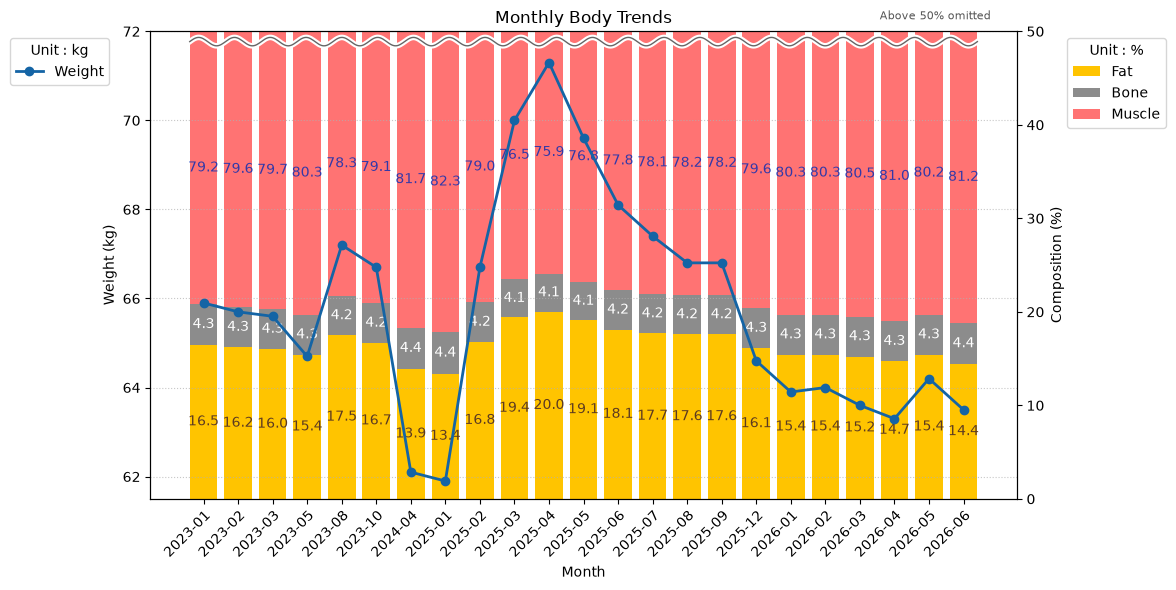

In [ ]:
# グラフの土台を作成
x = range(len(monthly_rates))

# 左軸：体重
fig, ax_weight = plt.subplots(figsize=(12, 6))

# 右軸：体組成
ax_percent = ax_weight.twinx()

# 体重の軸を手前に
ax_weight.set_zorder(ax_percent.get_zorder() + 1)

# 背景で棒グラフを隠さないようにする
ax_weight.patch.set_visible(False)


# 体重の折れ線グラフ
ax_weight.plot(
    x,
    monthly_rates["体重 (kg)"],
    color="#1464A5",
    marker="o",
    linewidth=2,
    label="Weight",
    zorder=10
)


# 筋肉率：棒グラフを上に
muscle_bars = ax_percent.bar(
    x,
    monthly_rates["筋肉率 %"],
    bottom=(
        monthly_rates["体脂肪率 %"]
        + monthly_rates["骨量率 %"]
    ),
    color="#FF0000",
    label="Muscle",
    alpha=0.55
)

# 筋肉率：数値をbarの中に表示
ax_percent.bar_label(
    muscle_bars,
    labels=[
        f"{value:.1f}"
        for value in monthly_rates["筋肉率 %"]
    ],
    label_type="center",
    fontsize=10,
    color="#002AB6",
    alpha=0.8
)


# 骨量率：棒グラフを筋肉と体脂肪の間に
bone_bars = ax_percent.bar(
    x,
    monthly_rates["骨量率 %"],
bottom=monthly_rates["体脂肪率 %"],
color="#70706F",
label="Bone",
alpha=0.8
)

#骨量率：数値をbarの中に表示
ax_percent.bar_label(
    bone_bars,
    labels=[
        f"{value:.1f}"
        for value in monthly_rates["骨量率 %"]
    ],
    label_type="center",
    fontsize=10,
    color="#FFFFFF"
)


# 体脂肪率：棒グラフを下に
body_fat_bars = ax_percent.bar(
    x,
    monthly_rates["体脂肪率 %"],
    color="#FFC400",
    label="Fat",
    alpha=1
)

# 体脂肪率：数値をbarの中に表示
ax_percent.bar_label(
    body_fat_bars,
    labels=[
        f"{value:.1f}"
        for value in monthly_rates["体脂肪率 %"]
    ],
    label_type="center",
    fontsize=10,
    color="#5C3A21"
)


# グラフ全体に1本の長い波線
wave_x = np.linspace(
    muscle_bars[0].get_x(),
    muscle_bars[-1].get_x() + muscle_bars[-1].get_width(),
    600
)

wave_y = 48.9 + 0.45 * np.sin(
    np.linspace(0, 44 * np.pi, 600)
)

# 背景を白く切る
ax_percent.plot(
    wave_x,
    wave_y,
    color="white",
    linewidth=4,
    zorder=5
)

# 波線を描く
ax_percent.plot(
    wave_x,
    wave_y,
    color="#666666",
    linewidth=1,
    zorder=6
)


# 省略範囲を明記
ax_percent.text(
    0.97,
    1.02,
    "Above 50% omitted",
    transform=ax_percent.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="#555555"
)

# 背景：薄い方眼
ax_weight.grid(
    axis="y",
    linestyle=":",
    alpha=0.7
)

# 凡例：右上の隅に移動、Fatを上、Mucを下に
handles, labels = ax_percent.get_legend_handles_labels()

ax_percent.legend(
    handles[::-1],
    labels[::-1],
    title="Unit : %",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

ax_weight.legend(
    title="Unit : kg",
    loc="upper left",
    bbox_to_anchor=(-0.17,1)
)


ax_weight.set_title("Monthly Body Trends")
ax_weight.set_xlabel("Month")
ax_weight.set_ylabel("Weight (kg)")
ax_weight.set_ylim(61.5,72)

ax_percent.set_ylabel("Composition (%)")
ax_percent.set_ylim(0, 50)

ax_weight.set_xticks(x)
ax_weight.set_xticklabels(
    monthly_rates["年月"],
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

plt.tight_layout()
plt.show()

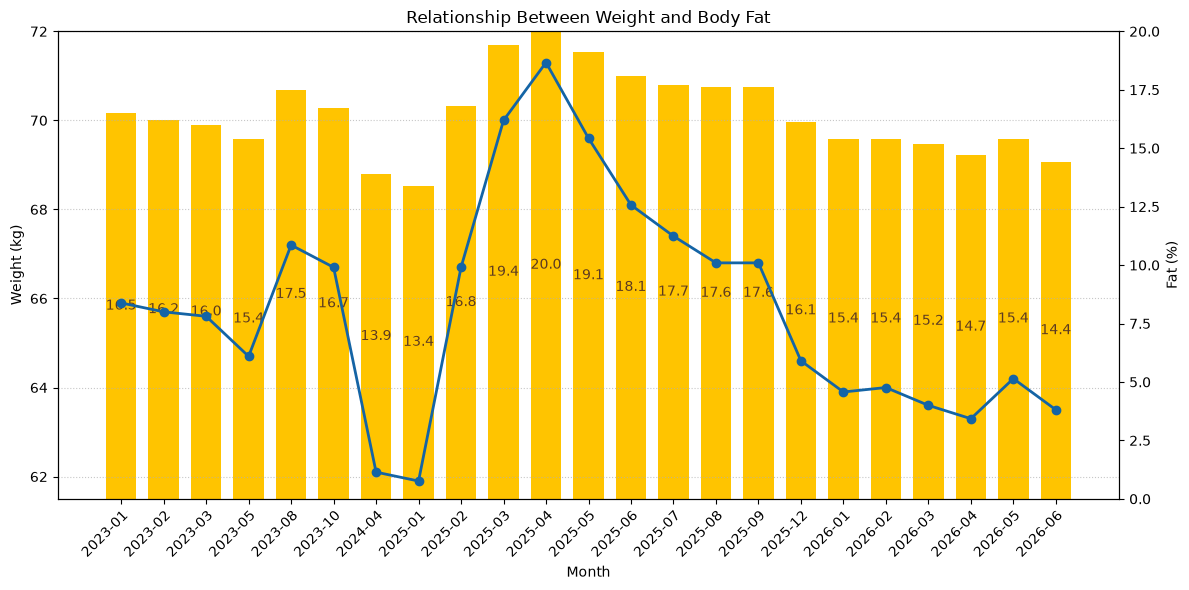

In [ ]:
# 月別の平均
monthly_rates = (
    df.groupby("年月", as_index=False)
    [["体重 (kg)", "筋肉率 %","骨量率 %", "体脂肪率 %"]]
    .mean()
    .round(1)
)

x = range(len(monthly_rates))

# 左軸：体重
fig, ax_weight = plt.subplots(figsize=(12, 6))

# 右軸：体組成
ax_percent = ax_weight.twinx()

# 体重の軸を手前に
ax_weight.set_zorder(ax_percent.get_zorder() + 1)

# 背景で棒グラフを隠さないようにする
ax_weight.patch.set_visible(False)

# 体重の折れ線グラフ
ax_weight.plot(
    x,
    monthly_rates["体重 (kg)"],
    color="#1464A5",
    marker="o",
    linewidth=2,
    label="Weight",
    zorder=10
)

# 体脂肪率の棒グラフ
body_fat_bars = ax_percent.bar(
    x,
    monthly_rates["体脂肪率 %"],
    width=0.72,
    color="#FFC400",
    label="Body Fat"
)

# 棒グラフの中心に数値を表示
ax_percent.bar_label(
    body_fat_bars,
    labels=[
        f"{value:.1f}"
        for value in monthly_rates["体脂肪率 %"]
    ],
    label_type="center",
    fontsize=10,
    color="#5C3A21"
)

# 背景：薄い方眼
ax_weight.grid(
    axis="y",
    linestyle=":",
    alpha=0.7
)

ax_weight.set_title("Relationship Between Weight and Body Fat")
ax_weight.set_ylabel("Weight (kg)")
ax_weight.set_ylim(61.5, 72)

ax_percent.set_ylabel("Fat (%)")
ax_percent.set_ylim(0, 20)

ax_weight.set_xlabel("Month")

ax_weight.set_xticks(x)
ax_weight.set_xticklabels(
    monthly_rates["年月"].astype(str),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

plt.tight_layout()
plt.show()
